# 09 · กราฟ 3 มิติและแอนิเมชัน what-if

สองรูปนี้ใช้ประกอบการนำเสนอ ไม่ได้เป็นส่วนของการทดสอบสมมติฐาน
และใช้**ผู้ตอบทั้งหมดรวมผู้ที่ไม่ผ่านข้อดัก** (`survey`) ต่างจาก notebook อื่น

In [1]:
import os
import pathlib
import sys

# notebook.nvim starts the kernel in nvim's cwd; step into codingpy/ so common.py
# and data/ are found when the notebook is opened from the repo root
if pathlib.Path("codingpy/common.py").is_file():
    os.chdir("codingpy")
    sys.path.insert(0, os.getcwd())

%matplotlib inline

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.animation import FuncAnimation, PillowWriter

from common import FIG_DIR, SEED, load_data

survey = load_data()  # every response, attention-check failures included

## 9.1 โซเชียลมีเดีย × การนอน → คะแนน DASS-21 รวม

จุดคือผู้ตอบแต่ละคน ระนาบคือสมการ least squares `dass_total = b0 + b1·social_media_hours + b2·sleep_hours`
แยกตามเพศ เพศต่างกันทั้งสีและรูปทรงของจุด

load_data: 121 row, 41 columns (seed=42)
Female: dass_total = 23.93 + -0.22*social_media_hours + 1.49*sleep_hours  (R²=0.014, n=62, mean DASS=31.5)
Male: dass_total = 51.60 + -0.95*social_media_hours + -1.58*sleep_hours  (R²=0.033, n=58, mean DASS=34.8)


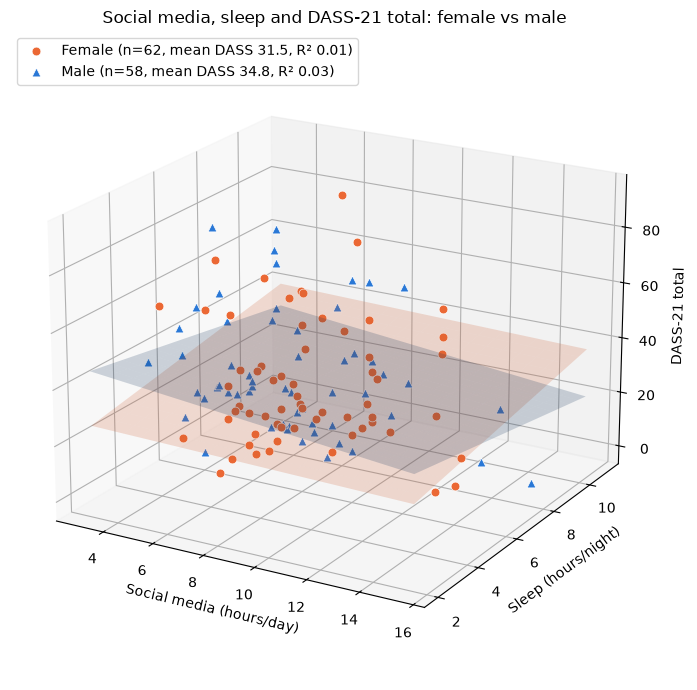

In [3]:
# these two figures carry English labels and were drawn in matplotlib's default face
plt.rcParams["font.family"] = matplotlib.rcParamsDefault["font.family"]

print(f"load_data: {survey.shape[0]} row, {survey.shape[1]} columns (seed={SEED})")

# 3D: social media hours x sleep hours -> DASS total, one least-squares plane per gender
cols = ["social_media_hours", "sleep_hours", "dass_total"]
d = survey[cols + ["gender"]].dropna()

# color + marker per gender, so the groups differ by more than color alone
STYLE = {"Female": ("#eb6834", "o"), "Male": ("#2a78d6", "^")}

gx, gy = np.meshgrid(
    np.linspace(d["social_media_hours"].min(), d["social_media_hours"].max(), 20),
    np.linspace(d["sleep_hours"].min(), d["sleep_hours"].max(), 20),
)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(projection="3d")

for gender, (color, marker) in STYLE.items():
    g = d[d["gender"] == gender]
    x, y, z = (g[c].to_numpy(dtype=float) for c in cols)

    # z = b0 + b1*x + b2*y
    X = np.column_stack([np.ones_like(x), x, y])
    b, *_ = np.linalg.lstsq(X, z, rcond=None)
    r2 = 1 - np.sum((z - X @ b) ** 2) / np.sum((z - z.mean()) ** 2)
    print(
        f"{gender}: dass_total = {b[0]:.2f} + {b[1]:.2f}*social_media_hours "
        f"+ {b[2]:.2f}*sleep_hours  (R²={r2:.3f}, n={len(g)}, mean DASS={z.mean():.1f})"
    )

    ax.scatter(
        x,
        y,
        z,
        color=color,
        marker=marker,
        s=40,
        edgecolors="white",
        linewidths=0.5,
        depthshade=False,
        label=f"{gender} (n={len(g)}, mean DASS {z.mean():.1f}, R² {r2:.2f})",
    )
    ax.plot_surface(gx, gy, b[0] + b[1] * gx + b[2] * gy, color=color, alpha=0.2)

ax.set_xlabel("Social media (hours/day)")
ax.set_ylabel("Sleep (hours/night)")
ax.set_zlabel("DASS-21 total")
ax.set_title("Social media, sleep and DASS-21 total: female vs male")
ax.view_init(elev=20, azim=-60)
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "3d-usage-sleep-dass.png", dpi=200)
plt.show()

## 9.2 What-if: ถ้าเพิ่มชั่วโมงใช้โซเชียลมีเดียทีละชั่วโมง

เลื่อนชั่วโมงใช้งานจาก 0 ถึง 15 ชั่วโมงต่อวัน แล้วตามดูคะแนน DASS-21 รวมที่ระนาบของแต่ละเพศทำนาย
โดยตรึงชั่วโมงนอนไว้ที่ค่าเฉลี่ยของเพศนั้น จึงมีเพียงชั่วโมงใช้งานที่เปลี่ยน
แบบสอบถามมีคำตอบเฉพาะช่วง 3 ถึง 15.5 ชั่วโมงต่อวัน เฟรมที่ต่ำกว่า 3 ชั่วโมงจึงเป็นการคาดนอกช่วงข้อมูล (ชื่อกราฟจะเขียนกำกับ)

เซลล์แรกคำนวณค่าทำนาย เซลล์ถัดไปวาดและบันทึกเป็นไฟล์ GIF รูปที่แสดงใน notebook คือเฟรมสุดท้าย

In [4]:
HOURS = np.arange(0, 16)  # 0, 1, ..., 15 hours of social media per day
COLS = ["social_media_hours", "sleep_hours", "dass_total"]
GIF_PATH = FIG_DIR / "what-if-social-media.gif"
Z_MAX = 100


def fit_plane(g: pd.DataFrame) -> np.ndarray:
    """Least-squares b for dass_total = b0 + b1*social_media_hours + b2*sleep_hours."""
    x, y, z = (g[c].to_numpy(dtype=float) for c in COLS)
    X = np.column_stack([np.ones_like(x), x, y])
    b, *_ = np.linalg.lstsq(X, z, rcond=None)
    return b


d = survey[COLS + ["gender"]].dropna()
low, high = d["social_media_hours"].min(), d["social_media_hours"].max()

# gender -> (rows, plane, mean sleep, predicted DASS for every hour in HOURS)
fits = {}
for gender in STYLE:
    g = d[d["gender"] == gender]
    b = fit_plane(g)
    sleep = g["sleep_hours"].mean()
    pred = b[0] + b[1] * HOURS + b[2] * sleep
    fits[gender] = (g, b, sleep, pred)
    print(
        f"{gender}: each +1 h social media -> DASS {b[1]:+.2f} "
        f"(sleep held at {sleep:.1f} h): {HOURS[0]} h = {pred[0]:.1f}, "
        f"{HOURS[-1]} h = {pred[-1]:.1f}"
    )

Female: each +1 h social media -> DASS -0.22 (sleep held at 6.3 h): 0 h = 33.3, 15 h = 30.0
Male: each +1 h social media -> DASS -0.95 (sleep held at 6.1 h): 0 h = 41.9, 15 h = 27.7


saved: ../figures/what-if-social-media.gif


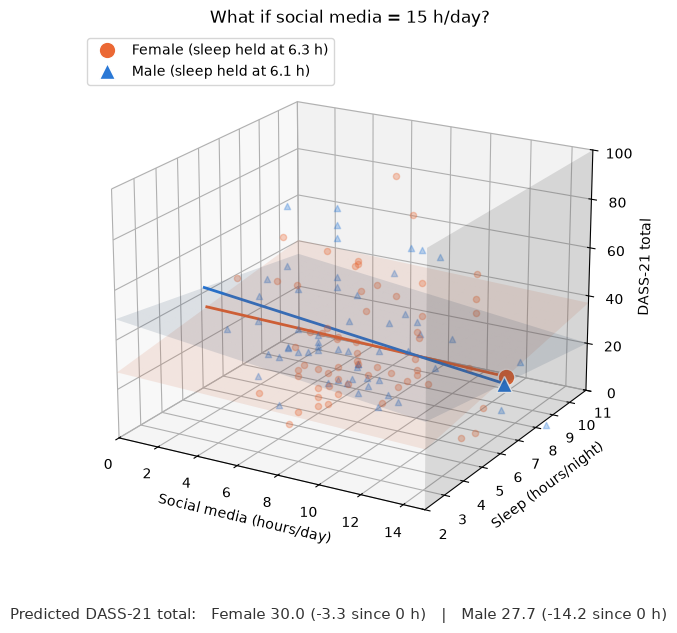

In [5]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(projection="3d")

y_min, y_max = d["sleep_hours"].min(), d["sleep_hours"].max()
gx, gy = np.meshgrid(np.linspace(HOURS[0], HOURS[-1], 20), np.linspace(y_min, y_max, 20))
# the moving "you are here" wall at the current hour
wall_y, wall_z = np.meshgrid([y_min, y_max], [0, Z_MAX])

paths, dots = {}, {}
for gender, (color, marker) in STYLE.items():
    g, b, sleep, _ = fits[gender]
    # the real survey answers stay faint in the background for context
    ax.scatter(
        g["social_media_hours"],
        g["sleep_hours"],
        g["dass_total"],
        color=color,
        marker=marker,
        s=20,
        alpha=0.3,
        depthshade=False,
    )
    ax.plot_surface(gx, gy, b[0] + b[1] * gx + b[2] * gy, color=color, alpha=0.12)
    (paths[gender],) = ax.plot([], [], [], color=color, linewidth=2)
    (dots[gender],) = ax.plot(
        [],
        [],
        [],
        color=color,
        marker=marker,
        markersize=12,
        markeredgecolor="white",
        linestyle="",
        label=f"{gender} (sleep held at {sleep:.1f} h)",
    )

ax.set_xlim(HOURS[0], HOURS[-1])
ax.set_ylim(y_min, y_max)
ax.set_zlim(0, Z_MAX)
ax.set_xlabel("Social media (hours/day)")
ax.set_ylabel("Sleep (hours/night)")
ax.set_zlabel("DASS-21 total")
ax.view_init(elev=20, azim=-60)
ax.legend(loc="upper left")
caption = fig.text(0.5, 0.04, "", ha="center", fontsize=11, color="#333333")


def draw_wall(h: float):
    return ax.plot_surface(
        np.full_like(wall_y, h, dtype=float), wall_y, wall_z, color="#888888", alpha=0.15
    )


wall = [draw_wall(HOURS[0])]  # replaced every frame


def draw(i: int):
    h = HOURS[i]
    wall[0].remove()
    wall[0] = draw_wall(h)

    lines = []
    for gender in STYLE:
        _, _, sleep, pred = fits[gender]
        paths[gender].set_data_3d(HOURS[: i + 1], np.full(i + 1, sleep), pred[: i + 1])
        dots[gender].set_data_3d([h], [sleep], [pred[i]])
        lines.append(f"{gender} {pred[i]:.1f} ({pred[i] - pred[0]:+.1f} since 0 h)")

    outside = "  [outside survey range]" if not low <= h <= high else ""
    ax.set_title(f"What if social media = {h} h/day?{outside}")
    caption.set_text("Predicted DASS-21 total:   " + "   |   ".join(lines))


anim = FuncAnimation(fig, draw, frames=len(HOURS), interval=600, repeat_delay=1500)
anim.save(GIF_PATH, writer=PillowWriter(fps=2))
print(f"saved: {GIF_PATH}")
plt.show()

**อ่านผล** ระนาบทั้งสองแทบไม่อธิบายคะแนน (R² = 0.014 สำหรับหญิง และ 0.033 สำหรับชาย)
และความชันของชั่วโมงใช้งานติดลบทั้งสองเพศ (−0.22 และ −0.95 คะแนนต่อชั่วโมง) ซึ่งสอดคล้องกับ `03_q1_q3_correlation.ipynb` และ `06_q6_q7_regression.ipynb`
ว่าข้อมูลชุดนี้ไม่สนับสนุนว่ายิ่งใช้โซเชียลมีเดียมากคะแนนยิ่งสูง
แอนิเมชันจึงเป็นภาพประกอบของสมการ ไม่ใช่คำทำนายว่าลดเวลาใช้งานแล้วคะแนนจะเปลี่ยน